In [1]:
import pandas as pd

In [18]:
# Reload the CSV and add cluster_k4
pdc_switchers_csv = pd.read_csv(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_monthly_wide_clusters.csv')

print(pdc_switchers_csv.columns.tolist())

['idCas', 'Month_-12', 'Month_-11', 'Month_-10', 'Month_-9', 'Month_-8', 'Month_-7', 'Month_-6', 'Month_-5', 'Month_-4', 'Month_-3', 'Month_-2', 'Month_-1', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'cluster', 'cluster_k3', 'cluster_k4']


c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


k=2: silhouette=0.5395
k=3: silhouette=0.5299
k=4: silhouette=0.5505
k=5: silhouette=0.5078
k=6: silhouette=0.5144
k=7: silhouette=0.4940
k=8: silhouette=0.4721
k=9: silhouette=0.4747
k=10: silhouette=0.4793

Best k: 4


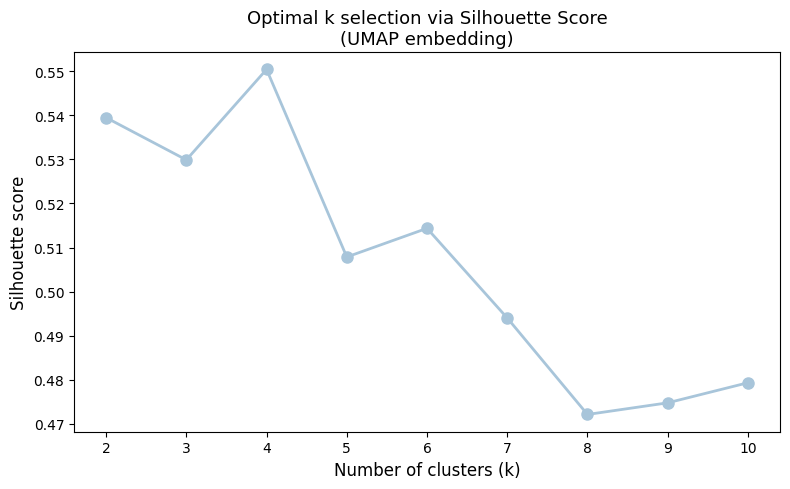

In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
import umap
import matplotlib.pyplot as plt

pdc_cols = [c for c in pdc_switchers_csv.columns if c.startswith('Month_')]
X = pdc_switchers_csv[pdc_cols].values

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embedding)
    score = silhouette_score(embedding, labels)
    silhouette_scores[k] = score
    print(f"k={k}: silhouette={score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 
         marker='o', color='#A8C5DA', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Silhouette score', fontsize=12)
plt.title('Optimal k selection via Silhouette Score\n(UMAP embedding)', fontsize=13)
plt.xticks(range(2, 11))
plt.tight_layout()

plt.show()

In [11]:
import numpy as np
from scipy.stats import entropy

for k_col in ['cluster', 'cluster_k3', 'cluster_k4']:
    cluster_counts = pdc_switchers_csv[k_col].value_counts().sort_index()
    probs = cluster_counts / cluster_counts.sum()
    e = entropy(probs, base=2)
    n_clusters = len(cluster_counts)
    max_entropy = np.log2(n_clusters)
    normalized_entropy = e / max_entropy
    print(f"\n{k_col}:")
    print(f"  Entropy: {e:.4f} bits")
    print(f"  Max possible entropy: {max_entropy:.4f} bits")
    print(f"  Normalized entropy: {normalized_entropy:.4f} (0=perfect separation, 1=uniform)")
    print(f"  Cluster sizes: {cluster_counts.to_dict()}")


cluster:
  Entropy: 0.9808 bits
  Max possible entropy: 1.0000 bits
  Normalized entropy: 0.9808 (0=perfect separation, 1=uniform)
  Cluster sizes: {0: 429, 1: 596}

cluster_k3:
  Entropy: 1.5270 bits
  Max possible entropy: 1.5850 bits
  Normalized entropy: 0.9635 (0=perfect separation, 1=uniform)
  Cluster sizes: {0: 420, 1: 394, 2: 211}

cluster_k4:
  Entropy: 1.9547 bits
  Max possible entropy: 2.0000 bits
  Normalized entropy: 0.9773 (0=perfect separation, 1=uniform)
  Cluster sizes: {0: 321, 1: 319, 2: 187, 3: 198}


In [16]:
for k_col in ['cluster_k4']:
    cluster_counts = pdc_switchers_csv[k_col].value_counts().sort_index()
    probs = cluster_counts / cluster_counts.sum()
    e = entropy(probs, base=2)
    n_clusters = len(cluster_counts)
    max_entropy = np.log2(n_clusters)
    normalized_entropy = e / max_entropy
    print(f"\n{k_col}:")
    print(f"  Entropy: {e:.4f} bits")
    print(f"  Normalized entropy: {normalized_entropy:.4f}")
    for cluster_id, count in cluster_counts.items():
        print(f"  Cluster {cluster_id}: {count} patients ({count/cluster_counts.sum()*100:.1f}%)")


cluster_k4:
  Entropy: 1.9547 bits
  Normalized entropy: 0.9773
  Cluster 0: 321 patients (31.3%)
  Cluster 1: 319 patients (31.1%)
  Cluster 2: 187 patients (18.2%)
  Cluster 3: 198 patients (19.3%)


In [17]:
# Entropía dentro de cada cluster para adherencia >= 80%
for k_col in ['cluster_k4']:
    print(f"\n{k_col}:")
    for cluster_id in sorted(pdc_switchers_csv[k_col].unique()):
        cluster_data = pdc_switchers_csv[pdc_switchers_csv[k_col] == cluster_id][pdc_cols]
        
        binary = (cluster_data >= 0.80).astype(int)
        adherent_prop = binary.mean(axis=1)
        
        hist, _ = np.histogram(adherent_prop, bins=10, range=(0,1), density=True)
        hist = hist + 1e-10
        e = entropy(hist, base=2)
        max_e = np.log2(10)  # max entropy with 10 bins
        normalized_e = e / max_e
        
        print(f"  Cluster {cluster_id}: entropy={e:.4f}, "
              f"normalized entropy={normalized_e:.4f} ({normalized_e*100:.1f}%), "
              f"mean adherent months={adherent_prop.mean()*100:.1f}%, "
              f"n={len(cluster_data)}")


cluster_k4:
  Cluster 0: entropy=2.0300, normalized entropy=0.6111 (61.1%), mean adherent months=50.7%, n=321
  Cluster 1: entropy=1.8032, normalized entropy=0.5428 (54.3%), mean adherent months=88.2%, n=319
  Cluster 2: entropy=2.4197, normalized entropy=0.7284 (72.8%), mean adherent months=24.3%, n=187
  Cluster 3: entropy=2.4088, normalized entropy=0.7251 (72.5%), mean adherent months=59.2%, n=198


In [23]:
# Model training for predicting cluster membership based on adherence patterns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
# Silence Optuna logs to keep output clean, remove if you want to see live tuning
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Load Data and Setup Features/Target
# (Adjust path if needed)
df = pd.read_csv(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_monthly_wide_clusters.csv')

pdc_cols = [c for c in df.columns if c.startswith('Month_')]
X = df[pdc_cols].values
y = df['cluster_k4'].values

# Ensure target labels are 0-indexed integers (0, 1, 2, 3)
unique_labels = np.unique(y)
n_classes = len(unique_labels)

# 2. Train-Test Split (80% / 20%) with stratification to keep cluster ratios intact
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Helper Function to Evaluate Models
def evaluate_multiclass_model(pipeline, X_test, y_test, n_classes):
    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)
    
    accuracy = accuracy_score(y_test, preds)
    # Using 'macro' averaging to treat all 4 clusters with equal weight
    precision = precision_score(y_test, preds, average='macro', zero_division=0)
    recall = recall_score(y_test, preds, average='macro', zero_division=0)
    
    # Binarize labels for One-Vs-Rest AUC calculation
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    auc = roc_auc_score(y_test_bin, probs, average='macro', multi_class='ovr')
    
    return {
        "AUC": auc,
        "Recall": recall,
        "Precision": precision,
        "Accuracy": accuracy
    }

# 4. Optuna Objective Functions
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        pipe = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(**params))])
        pipe.fit(X_tr, y_tr)
        
        y_val_bin = label_binarize(y_val, classes=range(n_classes))
        probs = pipe.predict_proba(X_val)
        scores.append(roc_auc_score(y_val_bin, probs, average='macro', multi_class='ovr'))
        
    return np.mean(scores)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        pipe = Pipeline([('scaler', StandardScaler()), ('model', XGBClassifier(**params))])
        pipe.fit(X_tr, y_tr)
        
        y_val_bin = label_binarize(y_val, classes=range(n_classes))
        probs = pipe.predict_proba(X_val)
        scores.append(roc_auc_score(y_val_bin, probs, average='macro', multi_class='ovr'))
        
    return np.mean(scores)

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        pipe = Pipeline([('scaler', StandardScaler()), ('model', LGBMClassifier(**params))])
        pipe.fit(X_tr, y_tr)
        
        y_val_bin = label_binarize(y_val, classes=range(n_classes))
        probs = pipe.predict_proba(X_val)
        scores.append(roc_auc_score(y_val_bin, probs, average='macro', multi_class='ovr'))
        
    return np.mean(scores)

# 5. Run Optimizations and Evaluate
results = {}
studies = {
    'Random Forest': (objective_rf, RandomForestClassifier),
    'XGBoost': (objective_xgb, XGBClassifier),
    'LightGBM': (objective_lgbm, LGBMClassifier)
}

print("Starting Hyperparameter Optimization via Optuna (5-Fold CV optimization based on AUC)...")

# Variables para rastrear cuál es el mejor pipeline absoluto
best_overall_auc = -1
final_pipe = None
best_model_name = ""

for name, (objective_func, model_class) in studies.items():
    print(f"\n--- Tuning {name} ---")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_func, n_trials=20) # 20 iteraciones por modelo
    
    print(f"Best CV AUC for {name}: {study.best_value:.4f}")
    print(f"Best Parameters: {study.best_params}")
    
    # Entrenar pipeline final para este modelo específico usando sus mejores parámetros
    best_params = study.best_params
    best_params['random_state'] = 42
    
    current_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model_class(**best_params))
    ])
    current_pipe.fit(X_train, y_train)
    
    # Evaluar en el 20% de test data independiente
    metrics = evaluate_multiclass_model(current_pipe, X_test, y_test, n_classes)
    results[name] = metrics
    
    # ¡La magia ocurre aquí! Comparamos el AUC actual de test con el mejor registrado
    if metrics['AUC'] > best_overall_auc:
        best_overall_auc = metrics['AUC']
        final_pipe = current_pipe  # Guardamos el objeto Pipeline ganador
        best_model_name = name

# 6. Print Final Matrix and Winner Info
print("\n================ FINAL TEST SET PERFORMANCE ================")
metrics_df = pd.DataFrame(results).T
print(metrics_df.to_string(formatters={
    'AUC': '{:,.2%}'.format,
    'Recall': '{:,.2%}'.format,
    'Precision': '{:,.2%}'.format,
    'Accuracy': '{:,.2%}'.format
}))

print("\n" + "="*60)
print(f"🏆 EL GANADOR ES: {best_model_name} (AUC: {best_overall_auc:.2%})")
print("La variable 'final_pipe' contiene ahora este modelo entrenado y listo para usar.")
print("="*60)

Starting Hyperparameter Optimization via Optuna (5-Fold CV optimization based on AUC)...

--- Tuning Random Forest ---
Best CV AUC for Random Forest: 0.9939
Best Parameters: {'n_estimators': 294, 'max_depth': 16}

--- Tuning XGBoost ---
Best CV AUC for XGBoost: 0.9950
Best Parameters: {'n_estimators': 249, 'learning_rate': 0.2983595636467654, 'max_depth': 3}

--- Tuning LightGBM ---


c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: U

Best CV AUC for LightGBM: 0.9944
Best Parameters: {'n_estimators': 212, 'learning_rate': 0.16888941798840723, 'max_depth': 3}

================ FINAL TEST SET PERFORMANCE ================
                 AUC Recall Precision Accuracy
Random Forest 99.34% 90.63%    92.12%   92.20%
XGBoost       99.48% 93.96%    94.62%   94.63%
LightGBM      99.39% 93.23%    93.98%   94.15%

🏆 EL GANADOR ES: XGBoost (AUC: 99.48%)
La variable 'final_pipe' contiene ahora este modelo entrenado y listo para usar.


c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


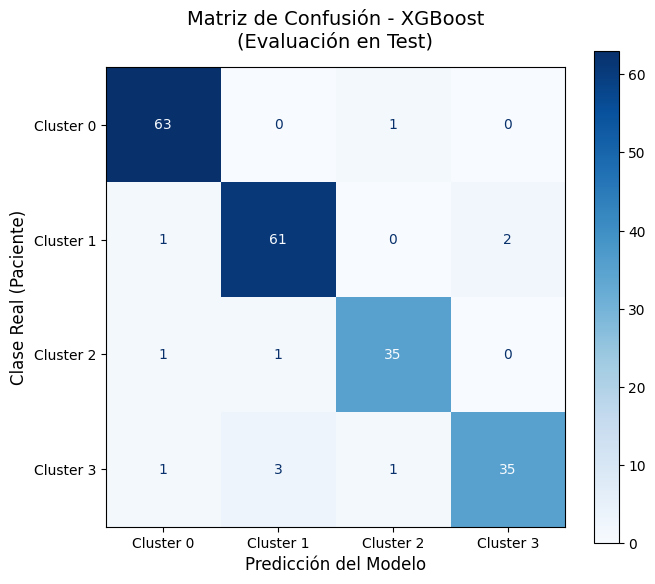

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generar las predicciones con el modelo ganador
y_pred = final_pipe.predict(X_test)

# 2. Calcular la matriz de confusión de forma numérica
cm = confusion_matrix(y_test, y_pred)

# 3. Configurar la visualización gráfica
# Definimos nombres claros para las etiquetas basados en tus clusters
target_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

# Dibujamos la matriz con una paleta de colores azulada muy profesional
disp.plot(cmap='Blues', ax=ax, values_format='d')

# Personalizar títulos y ejes
plt.title(f'Matriz de Confusión - {best_model_name}\n(Evaluación en Test)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real (Paciente)', fontsize=12)
plt.tight_layout()

In [25]:
final_pipe

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
